<a href="https://colab.research.google.com/github/Ab-tldr/Movie-review-Sentiment-Analysis/blob/main/EDA_air_quality.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###EDA

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
import missingno as msno

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATA_PATH = "/content/drive/MyDrive/air_quality/"

In [ ]:
df = pd.read_csv(DATA_PATH + "dataset/city_day.csv", low_memory=False)


In [ ]:
stations = pd.read_csv(DATA_PATH +'dataset/stations.csv')

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])


In [ ]:
len(df)

29531

<Figure size 1000x500 with 0 Axes>

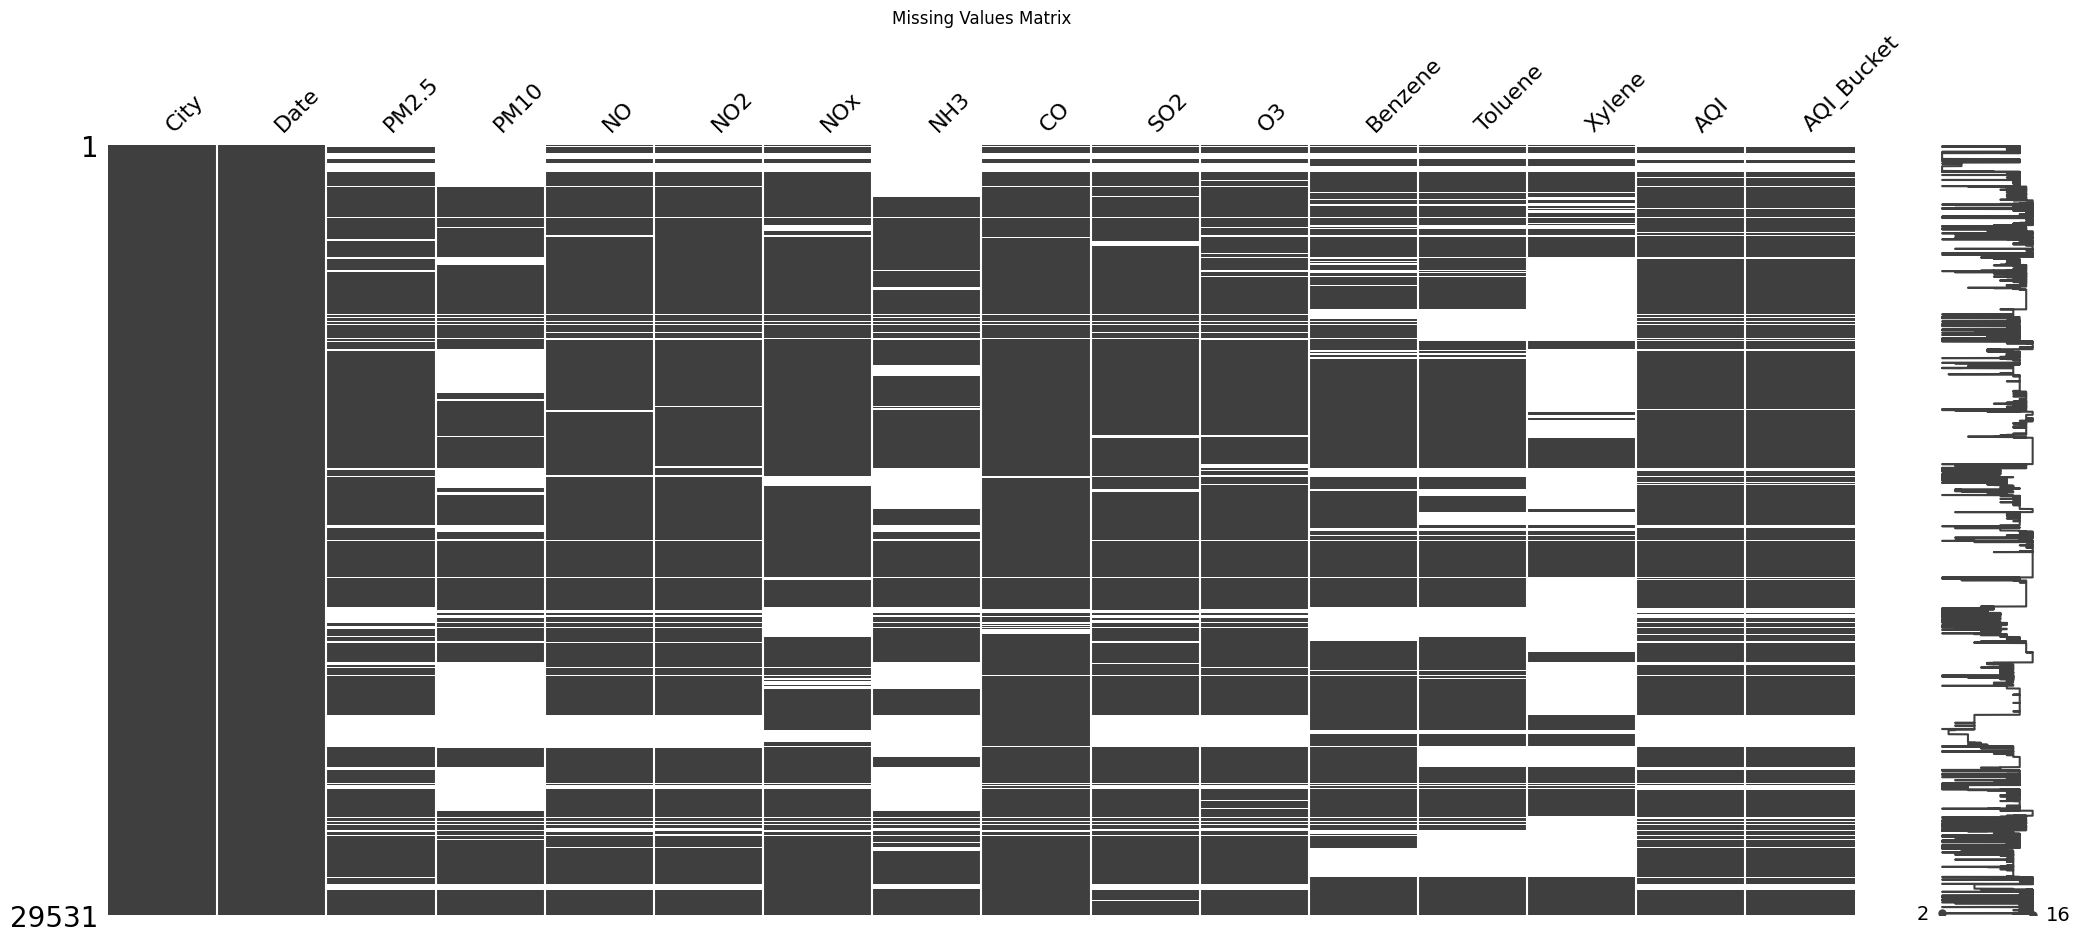

                                Date         PM2.5          PM10  \
count                          29531  24933.000000  18391.000000   
mean   2018-05-14 05:40:15.807118080     67.450578    118.127103   
min              2015-01-01 00:00:00      0.040000      0.010000   
25%              2017-04-16 00:00:00     28.820000     56.255000   
50%              2018-08-05 00:00:00     48.570000     95.680000   
75%              2019-09-03 00:00:00     80.590000    149.745000   
max              2020-07-01 00:00:00    949.990000   1000.000000   
std                              NaN     64.661449     90.605110   

                 NO           NO2           NOx           NH3            CO  \
count  25949.000000  25946.000000  25346.000000  19203.000000  27472.000000   
mean      17.574730     28.560659     32.309123     23.483476      2.248598   
min        0.020000      0.010000      0.000000      0.010000      0.000000   
25%        5.630000     11.750000     12.820000      8.580000      0.51

In [ ]:
plt.figure(figsize=(10, 5))
msno.matrix(df)
plt.title("Missing Values Matrix")
plt.show()

print(df.describe())
print(df.isnull().sum())

In [ ]:
df['PM2.5'].isnull().sum()/len(df)

np.float64(0.15570078900138837)

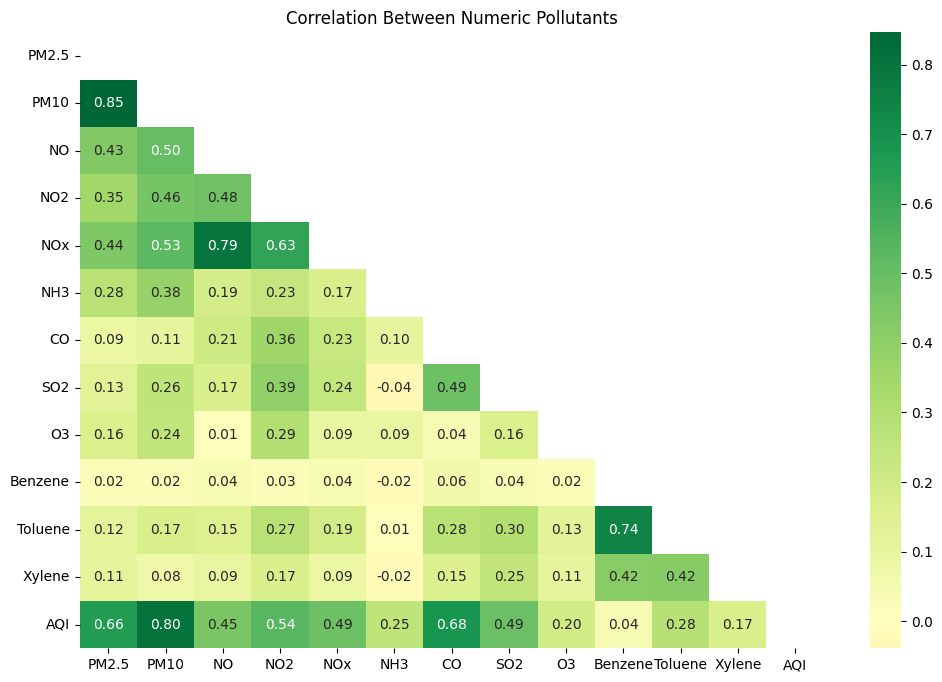

In [ ]:


numeric_df = df.select_dtypes(include=[np.number])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt=".2f", cmap='RdYlGn', center=0)
plt.title("Correlation Between Numeric Pollutants")
plt.show()

In [ ]:
df['AQI'].describe()

,AQI
count,24850.000000
mean,166.463581
std,140.696585
min,13.000000
25%,81.000000
50%,118.000000
75%,208.000000
max,2049.000000


In [ ]:
df['AQI'].isnull().sum()/len(df)

np.float64(0.15851139480545867)

/tmp/ipykernel_506/4143566884.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  city_monthly = city_df[['PM2.5', 'PM10', 'NO2']].resample('M').mean()


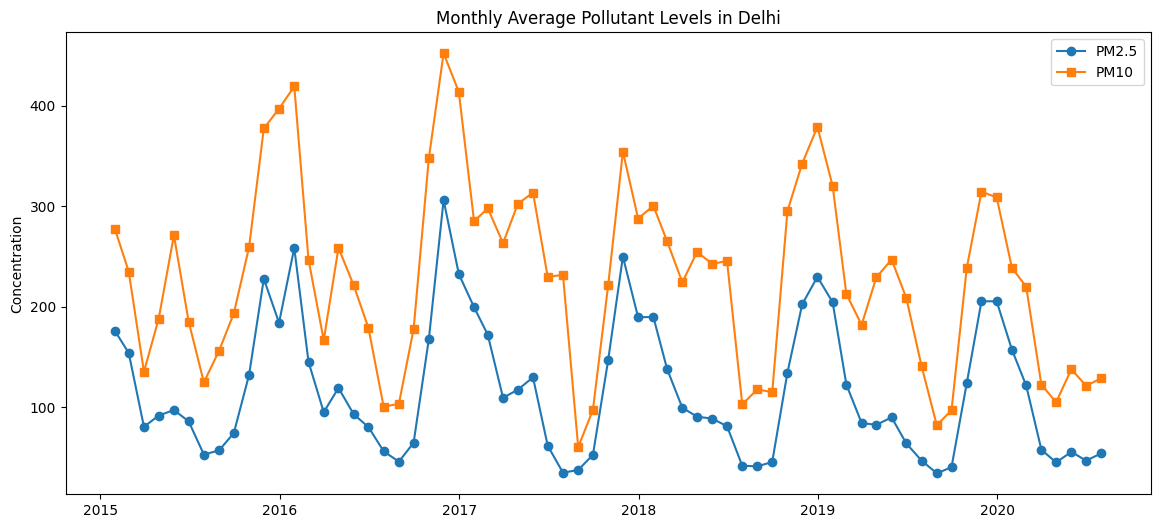

In [ ]:
city_name = 'Delhi'
city_df = df[df['City'] == city_name].set_index('Date')

city_monthly = city_df[['PM2.5', 'PM10', 'NO2']].resample('M').mean()

plt.figure(figsize=(14, 6))
plt.plot(city_monthly['PM2.5'], label='PM2.5', marker='o')
plt.plot(city_monthly['PM10'], label='PM10', marker='s')
plt.title(f"Monthly Average Pollutant Levels in {city_name}")
plt.ylabel("Concentration")
plt.legend()
plt.show()

In [ ]:
len(city_df)

2009

/tmp/ipython-input-3459190261.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_pollution.values, y=avg_pollution.index, palette='viridis')


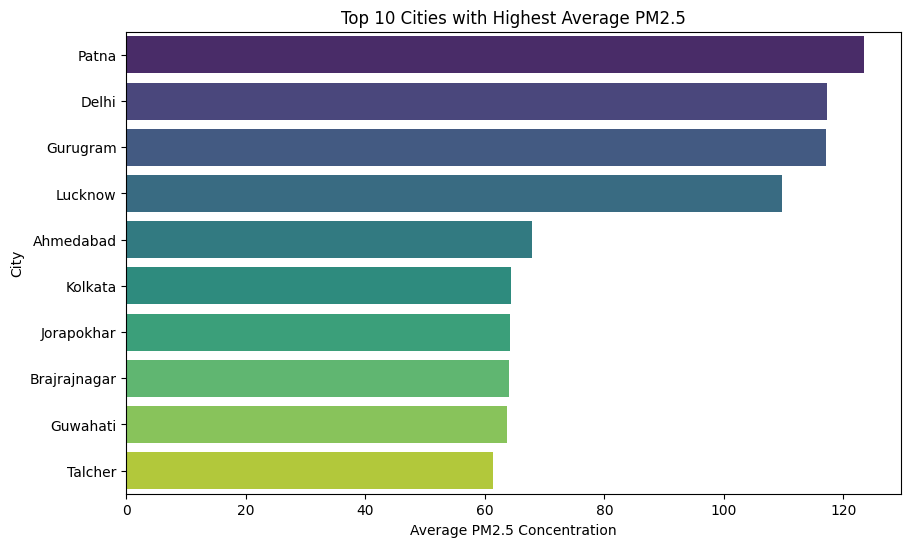

In [ ]:
avg_pollution = df.groupby('City')['PM2.5'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_pollution.values, y=avg_pollution.index, palette='viridis')
plt.title("Top 10 Cities with Highest Average PM2.5")
plt.xlabel("Average PM2.5 Concentration")
plt.show()

Missing Data Percentage:
 Xylene        61.322001
PM10          37.723071
NH3           34.973418
Toluene       27.229014
Benzene       19.041008
AQI           15.851139
AQI_Bucket    15.851139
PM2.5         15.570079
NOx           14.171549
O3            13.619586
SO2           13.050692
NO2           12.139785
NO            12.129626
CO             6.972334
Date           0.000000
City           0.000000
dtype: float64


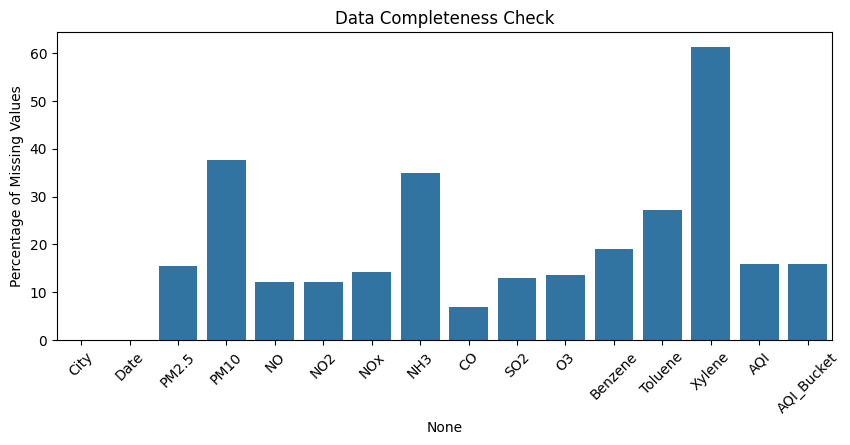

In [ ]:
missing_pct = (df.isnull().sum() / len(df)) * 100
print("Missing Data Percentage:\n", missing_pct.sort_values(ascending=False))

plt.figure(figsize=(10, 4))
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xticks(rotation=45)
plt.ylabel('Percentage of Missing Values')
plt.title('Data Completeness Check')
plt.show()

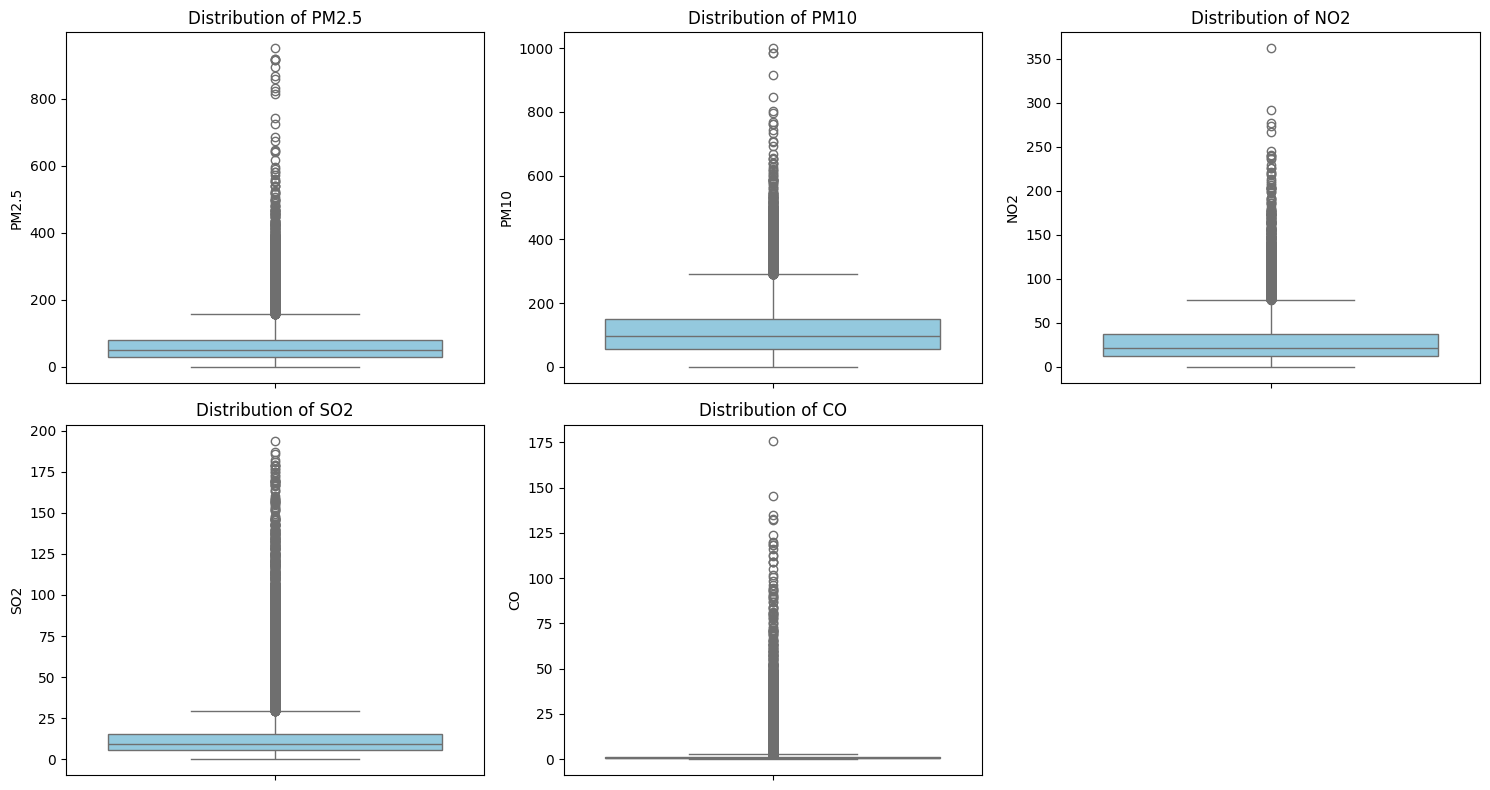

In [ ]:
pollutants_list = ['PM2.5', 'PM10', 'NO2', 'SO2', 'CO', 'Calculated_AQI']

plt.figure(figsize=(15, 8))
for i, col in enumerate(pollutants_list):
    if col in df.columns:
        plt.subplot(2, 3, i+1)
        sns.boxplot(y=df[col], color='skyblue')
        plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

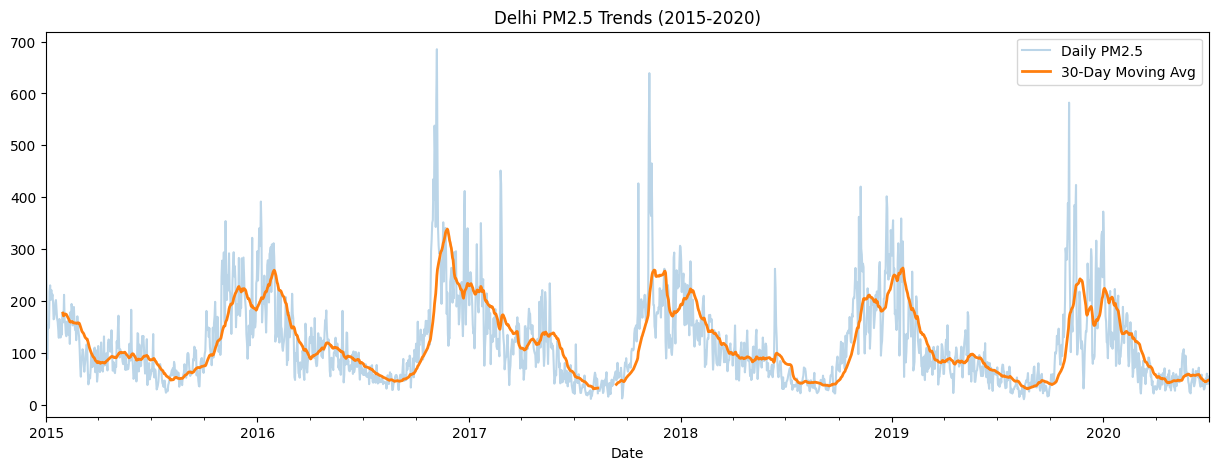

In [ ]:
delhi_eda = df[df['City'] == 'Delhi'].copy()
delhi_eda['Date'] = pd.to_datetime(delhi_eda['Date'])
delhi_eda = delhi_eda.set_index('Date')

plt.figure(figsize=(15, 5))
delhi_eda['PM2.5'].plot(label='Daily PM2.5', alpha=0.3)
delhi_eda['PM2.5'].rolling(window=30).mean().plot(label='30-Day Moving Avg', linewidth=2)
plt.title('Delhi PM2.5 Trends (2015-2020)')
plt.legend()
plt.show()

In [ ]:
len(delhi_eda)

2009

In [ ]:
total_rows = df.shape[0]
total_cols = df.shape[1]

print("Total data points (rows):", total_rows)
print("Total features (columns):", total_cols)

Total data points (rows): 29531
Total features (columns): 16


In [ ]:
pm25_null = df['PM2.5'].isnull().sum()
print("Missing values in PM2.5:", pm25_null)

Missing values in PM2.5: 4598


In [ ]:
delhi_df = df[df['City'] == 'Delhi']

print("Delhi dataset size:", delhi_df.shape)

Delhi dataset size: (2009, 16)


In [ ]:
delhi_pm25_null = delhi_df['PM2.5'].isnull().sum()

print("Missing PM2.5 values in Delhi:", delhi_pm25_null)

Missing PM2.5 values in Delhi: 2


In [ ]:
pm25_null_percent = (pm25_null / total_rows) * 100
delhi_pm25_null_percent = (delhi_pm25_null / delhi_df.shape[0]) * 100

print("Overall PM2.5 missing %:", pm25_null_percent)
print("Delhi PM2.5 missing %:", delhi_pm25_null_percent)

Overall PM2.5 missing %: 15.570078900138837
Delhi PM2.5 missing %: 0.09955201592832255
